In this notebook, we will analyze the multiplexed FISH experiment with GBM39 cells co-cultured with neurons.

Co-cultured sample was collected at Day 10, Day 20, Day 30. The control (Day 0) sample is the in vitro replicate 1 used in Figure 1 and 2.

Relevant figures can be found in Figure 5.

In [7]:
import os
import numpy as np
import pandas as pd

# Raw processing

The Day 10, 20 and 30 samples are collected and formatted the same way. Here, we will demonstrate with one time point (Day 20) as an example.

- ecDNA cts
- transcript counts
- dispersion score

## select FOVs

The GBM cells were seeded sparsely, so we start with selecting FOVs that have at least some GBM cells.

In [ ]:
## T drive is STARRFISH2
data_fld = r'T:\Brett\Day20_coCulture_03_26_2025\H1_P1F123_set1'
fovs = glob.glob(os.path.join(data_fld, 'Conv*.zarr'))
fovs = [os.path.basename(fl) for fl in fovs]
len(fovs)

In [ ]:
save_fld = r'T:\Brett\Day20_coCulture_03_26_2025\FOV_selection'
if not os.path.exists(save_fld):os.makedirs(save_fld)

In [ ]:
fov_counts = np.ones(len(fovs)) * -1 ## initialize an array of 0 for storage
for fov in tqdm(fovs):
# for fov in tqdm(['Conv_zscan1_0767', 'Conv_zscan1_0049']): ## test it on a GBM-rich FOV and purely neuronal FOV
    save_fl = os.path.join(save_fld, f"{fov.replace('.zarr', '')}_Xh_labels.npz")
    try:
        if os.path.exists(save_fl):
            ## pull directly
            Xh_with_labels = np.load(save_fl)['Xh_with_labels']
            unique_clusters = np.unique(Xh_with_labels[:, -1])
            num_clusters = len(unique_clusters[unique_clusters != -1])
        else:
            ## get Xh
            Xh, imDn_, im_raw = extract_bright_spots(fov = fov, data_fld = data_fld, icol = 1, dapi = False)
            ## get clusters
            Xh_with_labels, num_clusters, centroids = cluster_points_dbscan(Xh, eps=30, min_samples=5, centroid=True)
            ## save result
            np.savez_compressed(save_fl, Xh_with_labels = Xh_with_labels, centroids = centroids)
        
        ## store cell count in dict
        ifov = int(fov.replace('.zarr', '').split('_')[-1])
        fov_counts[ifov] = num_clusters
    except:
        print(f'{fov} failed :(')

In [ ]:
# save the FOVs for next step
ifovs = np.where(fov_counts>3)[0]
np.save(file = 'C:/GBM39/Day20_coCulture_03_26_2025/Day20_coCulture_03_26_2025_choseniFOV_cts3.npy', arr = ifovs)

## DNA cts

For each experiment, we imaged the first 3 5-Kb segments on the ecDNA.

### fitting

Fitted spots with mermake using default param

### DAPI segm

In [ ]:
## this function is adapter from ioMicro::new_segmentationV2
def run_segmentation(fl =r'\\192.168.0.100\bbfish100\DCBBL1_4week_6_2_2023\H1_MER_set1\Conv_zscan__030.zarr',
                     psf_file = '\\\\192.168.0.100\\bbfish100\\DCBBL1_4week_6_2_2023\\MERFISH_Analysis\\psf_750_Scope3_final.npy',
                     p1=-500,p99=1500,mean_dapi = None,sdapi = 100,
                    save_folder = r'\\192.168.0.100\bbfish100\DCBBL1_4week_6_2_2023\MERFISH_Analysis',redo=False,plt_val=False, 
                     flat_field_tag = r'T:\Brett\coCulture_03_11_2025\flat_field' + os.sep):

    ''' Optimized for cell line '''
    segm_folder = save_folder+'Segmentation'
    if not os.path.exists(segm_folder): os.makedirs(segm_folder)
    fl_dapi = fl
    save_fl  = segm_folder+os.sep+os.path.basename(fl_dapi).split('.')[0]+'--'+os.path.basename(os.path.dirname(fl_dapi))+'--dapi_segm.npz'
    if redo or (not os.path.exists(save_fl)):
    
        im = read_im(fl)
        im_dapi = np.array(im[-1],dtype=np.float32)
        imd = im_dapi
        
        ## include flat field
        
        im_med_fl=flat_field_tag+r'med_col_raw3.npz'
        immed = cv2.blur(np.load(im_med_fl)['im'],(20,20))
        immed=immed/np.median(immed)
        im_dapi = im_dapi/immed
        
        if psf_file is not None:
            psf = np.load(psf_file, allow_pickle = True)
            imd = full_deconv(im_dapi,s_=500,pad=100,psf=psf,parameters={'method': 'wiener', 'beta': 0.01},gpu=True,force=True)
        #im_dapi_ = norm_slice(imd,s=sdapi)


        img = imd[::1,::4,::4]

        from cellpose import models, io,utils
        from scipy import ndimage
        model = models.Cellpose(gpu=True, model_type='nuclei')
        # masks, flows, styles, diams = model.eval(img,z_axis=0, diameter=20, channels=[0,0],
        #                                          flow_threshold=0.4,cellprob_threshold=0,normalize=True,
        #                                          do_3D=False,stitch_threshold=0.5,
        #                                          progress=True)
        masks, flows, styles, diams = model.eval(img, batch_size=8,
            channels=[0, 0],
            channel_axis=None,
            invert=False,
            normalize=True,
            diameter=20.0,
            do_3D=False,cellprob_threshold=-10,stitch_threshold=0.5,
            flow_threshold=-10,min_size = 1000)

        segm = masks
        shape = np.array(im[-1].shape)
        # cells,volms = np.unique(segm,return_counts=True)
        # cells,volms = cells[1:],volms[1:]
        # segm_ = replace_mat(segm,cells[volms<7000],0)
        segm_ = segm
        np.savez_compressed(save_fl,segm = segm_,shape = shape)
    return save_fl

In [ ]:
def get_dapi_image_name(fov, fld):
    # set_ = fov.split('_')[0].split('Conv_zscan')[-1]
    set_ = fov.split('_')[1].split('zscan')[-1]
    fl = rf'{fld}_set{set_}\{fov}.zarr'
    return fl

In [ ]:
ufovs = [f'Conv_zscan1_{str(ifov).zfill(4)}' for ifov in ifovs]

In [ ]:
psf_file = r'T:\Brett\scope5\psfs\dic_psfff_Zane2800.pkl'
save_folder = r'T:\Brett\Day20_coCulture_03_26_2025' + os.sep

In [ ]:
for fov in tqdm(ufovs):
    run_segmentation(fl = get_dapi_image_name(fov, fld = r'T:\Brett\Day20_coCulture_03_26_2025\H1_P1F123'),
                     psf_file = psf_file,
                     p1=-500,p99=1500,mean_dapi = None,sdapi = 100,
                    save_folder = save_folder,redo=True,plt_val=False,
                flat_field_tag = r'T:\Brett\Day20_coCulture_03_26_2025\flat_field' + os.sep)

### select bright spots

From the fitted spots, we select for bright spots for copy number quantificaton and also to compute the dispersion score per cell.

In [ ]:
save_fld = r'T:\Brett\Day20_coCulture_03_26_2025' + os.sep

In [ ]:
XF = get_Xh_fov(fov = fov,
           # set_ = fov.split('__')[0].split('Conv_zscan')[-1], 
           segm_fld = os.path.join(save_fld, 'Segmentation'),
            analysis_folder=os.path.join(save_fld, 'DNA_Analysis'),
            save_fld_traces=os.path.join(save_fld, 'DNA_Analysis'), 
            force = True, smFISH = True,
            pix_size = [0.4, 0.108333, 0.108333])

In [ ]:
medh, uRs = get_maxH_nan(XF)

In [ ]:
np.savez_compressed(os.path.join(save_fld, 'DNA_Analysis','medh_uRs.npz'), medh = medh, uRs = uRs, fov = fov)

In [ ]:
tag = 'Day20_coCulture_03_26_2025'

In [ ]:
## iterate thru
save_fld = rf'T:\Brett\{tag}\DNA_Analysis'
segm_fld = rf'T:\Brett\{tag}\Segmentation'
pix_size = [0.4, 0.108333, 0.108333]
for fov in tqdm(ufovs):
    get_Xh_fov(fov = fov,
           # set_ = fov.split('__')[0].split('Conv_zscan')[-1], 
           segm_fld = segm_fld,
            analysis_folder=save_fld,
            save_fld_traces=save_fld, 
            force = True, smFISH = True,
            pix_size = pix_size)
    XF = np.load(os.path.join(save_fld, rf'{fov}--XF.npz'))['XF']
    
    ## get bright spots for P1F2
    XF_ = select_britgher_spots(XF,medh, uRs, th_h=3)
    colocalized_points = find_colocalized_points(XF_, dth = 2) ## dth is in pixel space
    XF_col = colocalized_points[1] # take cy5
    
    ## get rgs(this also saves XF_col)
    info_rgs = get_rgs_fov(XF_col, fov, save_fld=save_fld, save = True, pix_size = pix_size, segm_fld = segm_fld)

# RNA cts

For each experiment, we sequentially imaged the EGFR exon and also marker genes for the GBM cells (VIM, TNC) and also marker genes for the neurons (NEFM, NEFL). 

## find bright spots

In [ ]:
## this is dataset specific
dic_R_genes = {}
for fl in glob.glob(f'{save_fld}/H*') :
    htag = os.path.basename(fl)
    hindex = int(htag.split('_')[0][1:])
    if hindex == 1:
        continue
    if hindex == 2:
        htag = htag.replace('H2_P4C12D1', 'H2_EGFR-exon_EGFR-intron_')
    genes = htag.split('_set')[0].split('_')[1:]
    for icol in range(3):
        dic_R_genes[int(hindex)*1000 + icol] = genes[icol]
dic_genes_R = dict(zip(dic_R_genes.values(), dic_R_genes.keys()))

In [ ]:
header = ['z','x','y','bk','corabs','habs','cor','isNuc', 'h','col','R', 'cell_id']
dic_header = dict(zip(header, range(len(header))))

In [ ]:
fov = 'Conv_zscan1_0804'

In [ ]:
XF_RNA = get_Xh_fov_RNA(fov = fov,
           # set_ = fov.split('__')[0].split('Conv_zscan')[-1], 
           segm_fld = os.path.join(save_fld, 'Segmentation'),
            analysis_folder=os.path.join(save_fld, 'DNA_analysis'),
            save_fld_traces=os.path.join(save_fld, 'RNA_analysis'), 
            force = True, smFISH = False,
            pix_size = pix_size, save = True)

In [ ]:
### get ref medh and URs
medh,uRs = get_maxH_nan(XF_RNA)

In [ ]:
## for loop it!

dic_ufovcell_cts = {}
for fov in tqdm(fovs):
# for fov in ['Conv_zscan1_0804']:
    XF_RNA = get_Xh_fov_RNA(fov = fov,
           # set_ = fov.split('__')[0].split('Conv_zscan')[-1], 
           segm_fld = os.path.join(save_fld, 'Segmentation'),
            analysis_folder=os.path.join(save_fld, 'DNA_analysis'),
            save_fld_traces=os.path.join(save_fld, 'RNA_analysis'), 
            force = False, smFISH = False,
            pix_size = pix_size, save = True)

    
    XF_RNA = np.load(os.path.join(save_fld, 'RNA_analysis', f'{fov}--XF_RNA.npz'))['XF']
    XF_RNA_b = get_counts_per_fov(fov, XF_RNA, save_fld = save_fld, save = True)
    ufovcells = np.load(os.path.join(save_fld, 'RNA_analysis', f'{fov}--XF_cts.npz'))['ufovcells']
    
    ##
    genes = ['VIM', 'TNC', 'NEFL', 'NEFM', 'EGFR-exon', 'EGFR-intron']
    for geneR in genes:
        dic_ucells_cts = get_gene_cts_per_cell(XF_RNA_b, geneR = dic_genes_R[geneR], nuc_only = True) ### only consider counts in DAPI
        ## format
        for ufovcell in ufovcells:
            ucell = ufovcell % 10**5
            if ufovcell not in dic_ufovcell_cts.keys():
                dic_ufovcell_cts[ufovcell] = []
            
            if ucell in dic_ucells_cts.keys():
                dic_ufovcell_cts[ufovcell].append(dic_ucells_cts[ucell])
            else:
                dic_ufovcell_cts[ufovcell].append(0) ## 0 otherwise

In [ ]:
df_RNA_cts = pd.DataFrame(dic_ufovcell_cts)

In [ ]:
df_save = df_RNA_cts.T
df_save.columns = genes

In [1]:
experiment_tag = 'Day20_coCulture_03_26_2025'

In [ ]:
df_save.to_csv(f'C:/GBM39/{experiment_tag}/050525-{experiment_tag}-RNA.csv')

## process the EGFR exon and intron again to be consistent with the control

In [ ]:
def process_RNA_coculture(tag, th_hlow = 3, EGFR_iQs = [2000, 2001], dry_run = False):
    RNA_fld = dic_tag_input_fld[tag]
    XF_fls = glob.glob(os.path.join(RNA_fld, '*XF_RNA.npz'))
    fovs = [os.path.basename(fl).split('--')[0] for fl in XF_fls]

    medh_all = np.load(os.path.join(RNA_fld, 'medh_uRs_RNA.npz'))['medh']
    uRs_all = np.load(os.path.join(RNA_fld, 'medh_uRs_RNA.npz'))['uRs']

    intron_analysis_folder = os.path.join(RNA_fld, 'anchor_points-iQ')
    os.makedirs(intron_analysis_folder, exist_ok=True)

    if dry_run: 
        fovs = fovs[:1]
    ## loop thru to get RNA counts
    ifovcells = []
    X_EGFR_list = []
    for fov in tqdm(fovs):
        ifov = int(fov.split('_')[-1])
        XF = np.load(os.path.join(RNA_fld, f'{fov}--XF_RNA.npz'))['XF']

        for iQ in EGFR_iQs:
            ## get the bright spots
            X_EGFR = get_bright_points_per_R_coculture(XF, iR = iQ, 
                                    medh = medh_all, uRs = uRs_all,
                                        th_hlow = th_hlow, ## std above the min
                                        th_dd = 3, H_col = -4)
            if dry_run:
                X_EGFR_list.append(X_EGFR)

            for ucell in np.unique(XF[:, -1]):
                X_EGFR_cell = X_EGFR[X_EGFR[:, -1] == ucell]
                ifovcell = int(10**5 * ifov + ucell)
                # if len(X_EGFR_cell) > 100:
                #     print(f'ifovcell {ifovcell}: {len(X_EGFR_cell)}')

                # save this!
                save_fl = os.path.join(intron_analysis_folder, f'cell{ifovcell}--iQ{dic_iQ_EGFR[iQ]}--th_h{th_hlow}--XFb.npy')
                np.save(save_fl, X_EGFR_cell)

                ifovcells.append(ifovcell)
    if dry_run:
        return fov, X_EGFR_list
    
    ## format counts per cell
    list_EGFR_exon_intron_cts = []
    for ifovcell in tqdm(np.unique(ifovcells)):
        cell_val = [ifovcell]
        for iQ in EGFR_iQs:
            XFb = np.load(os.path.join(intron_analysis_folder, f'cell{ifovcell}--iQ{dic_iQ_EGFR[iQ]}--th_h{th_hlow}--XFb.npy'))
            cell_val.append(len(XFb))
        list_EGFR_exon_intron_cts.append(cell_val)

    df_cts = pd.DataFrame(list_EGFR_exon_intron_cts, columns = ['ifovcell', 'EGFR_exon', 'EGFR_intron'])
    df_cts['tag'] = tag
    
    return df_cts

In [ ]:
df_cts = process_RNA_coculture(tag =  tag, 
                                th_hlow = dic_tag_th[tag], 
                               EGFR_iQs = [2000, 2001], dry_run = False)

In [ ]:
df_cts.to_csv(rf'C:/GBM39/coCulture_03_11_2025/coculture_RNA_all_samples/011426__{tag}__df_EGFR_exon_intron_nuc__sameAsCtrl.csv')

# cell type identification

## import functions

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
def cluster_cells_CPM(df_cts, normalize = True):
    pseudocount = 0.0001
    data_norm = df_cts.T + pseudocount
    if normalize:
        data_normalized = data_norm.div(data_norm.sum(axis=1), axis=0)
        ## try normalzing to the total RNA counts first? (CPM)
        data_norm = data_normalized
    # else:
    #     data_norm = df_cts.T
    #     ## add pseudocount
    #     data_norm = data_norm + pseudocount
        # data_scaled_norm = data_norm.values
    
    ## Z score
    scaler = StandardScaler()
    data_scaled_norm = scaler.fit_transform(data_norm)        
        
    # return data_scaled_norm

    # Clustering
    kmeans = KMeans(n_clusters=2, random_state=42)  # Adjust n_clusters as needed
    clusters_norm = kmeans.fit_predict(data_scaled_norm)

    # Add clusters back to the original data
    data_norm['Cluster'] = clusters_norm
    
    return data_norm

## assign cell types

In [ ]:
markers_df = df_RNA_cts.iloc[:4, :]
marker_celltype = cluster_cells_CPM(markers_df, normalize = True)['Cluster']
sum(marker_celltype)

In [ ]:
EGFR_df = df_RNA_cts.iloc[4:, :]
EGFR_celltype = cluster_cells_CPM(EGFR_df, normalize = False)['Cluster']
sum(EGFR_celltype)

In [ ]:
## turn into three cell types: neuron, GBM, unsure
# Initialize with -1
all_merged_celltype = pd.Series(-1, index=marker_celltype.index)

# Apply logic
all_merged_celltype[(marker_celltype == 0) & (EGFR_celltype == 0)] = 0
all_merged_celltype[(marker_celltype == 1) & (EGFR_celltype == 1)] = 1
all_merged_celltype[(marker_celltype == 1) & (EGFR_celltype == 0)] = 2
all_merged_celltype[(marker_celltype == 0) & (EGFR_celltype == 1)] = 3

# merge DNA and RNA

From the code blocks above, two important files were generated per experiment:
- RNA counts: 'C:/GBM39/{experiment_tag}/050525-{experiment_tag}-RNA.csv'
- rgs_all with cell types: f'C:/GBM39/{experiment_tag}/050525-{{experiment_tag}}-df_rgs.csv'

## for Day 20

In [8]:
## now read in the master info rgs
rgs_all = []
for fov in tqdm(fovs):
    rgs_fl = os.path.join(rf'{save_fld}\DNA_analysis', f'{fov}--rgs.npz')
    X = np.load(rgs_fl)['info_rgs']
    rgs_all.extend(X)
rgs_all = np.array(rgs_all)

In [9]:
df_rgs = pd.DataFrame(rgs_all, columns = ['ifovcell','necdna','volm','rg','norm_rg'])
df_rgs.set_index('ifovcell',inplace = True)

In [10]:
df_rgs['celltype'] = all_merged_celltype
df_rgs['celltype_label'] = df_rgs['celltype'].map(label_map)

In [11]:
df_rgs = pd.read_csv(rf'C:/GBM39/{experiment_tag}/050525-{experiment_tag}-df_rgs.csv', index_col = 0)

In [12]:
df_rgs

,necdna,volm,rg,norm_rg,celltype,celltype_label
ifovcell,,,,,,
800003.0,109.0,40503.0,5.705890,0.724644,1.0,GBM
800004.0,3.0,40830.0,5.483402,0.935957,0.0,neurons
800005.0,13.0,38202.0,5.958429,0.876697,0.0,neurons
800006.0,9.0,22273.0,4.455269,0.771554,0.0,neurons
800008.0,70.0,50239.0,5.279254,0.666732,1.0,GBM
...,...,...,...,...,...,...
155000163.0,1.0,18811.0,0.000000,NaN,0.0,neurons
155000167.0,1.0,8351.0,0.000000,NaN,0.0,neurons
155000178.0,38.0,5494.0,3.692241,0.789929,2.0,unsure astrocytes?


In [ ]:
df_rgs.to_csv(rf'C:/GBM39/{experiment_tag}/050525-{experiment_tag}-df_rgs.csv')

## compile all time points

In [13]:
tags =['invirto_030125','coCulture_03_11_2025','Day20_coCulture_03_26_2025','Day30_coCulture_04_11_2025_V1', 'Day30_coCulture_04_14_2025_V2']

In [ ]:
df_rgs_list = []
for tag in tags:
    save_fl = glob.glob(f'C:/GBM39/{tag}/*df_rgs.csv')[0]
    df_rgs = pd.read_csv(save_fl)
    df_rgs['tag'] = tag  # add tag column
    df_rgs_list.append(df_rgs)
    print(f'{tag}: {df_rgs.shape}')
df_rgs_all = pd.concat(df_rgs_list)

In [ ]:
## read in the RNA as well
df_RNA_list = []
for tag in tags:
    save_fl = glob.glob(f'C:/GBM39/{tag}/*RNA.csv')[0]
    print(save_fl)
    if tag != 'invirto_030125':
        df_RNA = pd.read_csv(rf'C:/GBM39/coCulture_03_11_2025/coculture_RNA_all_samples/011426__{tag}__df_EGFR_exon_intron_nuc__sameAsCtrl.csv',
                            index_col = 0)
        df_RNA.rename(columns={'EGFR_exon': 'EGFR-exon', 'EGFR_intron': 'EGFR-intron'}, inplace=True)
    else:
        df_RNA = pd.read_csv(save_fl, index_col = 0)
        df_RNA['tag'] = tag
        
    df_RNA_list.append(df_RNA)
    print(f'{tag}: {df_RNA.shape}')
df_RNA_all = pd.concat(df_RNA_list)

In [ ]:
## now merge them together
df_all = pd.merge(df_rgs_all, df_RNA_all, on = ['ifovcell', 'tag'])
df_all

In [ ]:
df_all.to_csv(r'C:/GBM39/coCulture_03_11_2025/011426_df_comp_ctrlV2_coCultureDay102030_EGFR_redo.csv')

## filter

In [22]:
tag_plot_order =  ['Control', 'Day10', 'Day20', 'Day30','Day30_V2']
tag_plot_selected = ['Control', 'Day10', 'Day20', 'Day30']

In [23]:
df_all = pd.read_csv(r'C:/GBM39/coCulture_03_11_2025/011426_df_comp_ctrlV2_coCultureDay102030_EGFR_redo.csv', index_col = 0)

In [24]:
## keep only one Day 30 sample
df_all['tag_plot'] = df_all['tag'].replace(dict(zip(tags, tag_plot_order)))
df_all = df_all[df_all['tag_plot'] != 'Day30_V2']
df_all.shape

(101246, 12)

In [25]:
df_test = df_all.copy()
df_test = df_test[(df_test['celltype'] == 1) | (df_test['celltype'] == 2)]
df_test = df_test[(df_test['necdna'] >= 3) & (df_test['necdna'] <= 200)] #200
df_test = df_test[(df_test['EGFR-exon'] <= 1000)]
df_test.shape

(22378, 12)

In [26]:
df_test['EGFR-exon_log1p'] = np.log1p(df_test['EGFR-exon'])

In [27]:
df_test['necdna_log2'] = np.log2(df_test['necdna'] +1)

In [ ]:
# df_test.to_csv(r'C:/GBM39/coCulture_03_11_2025/011426_df_ctrlV2_coCultureDay102030_EGFR_redo_final.csv')

# plot

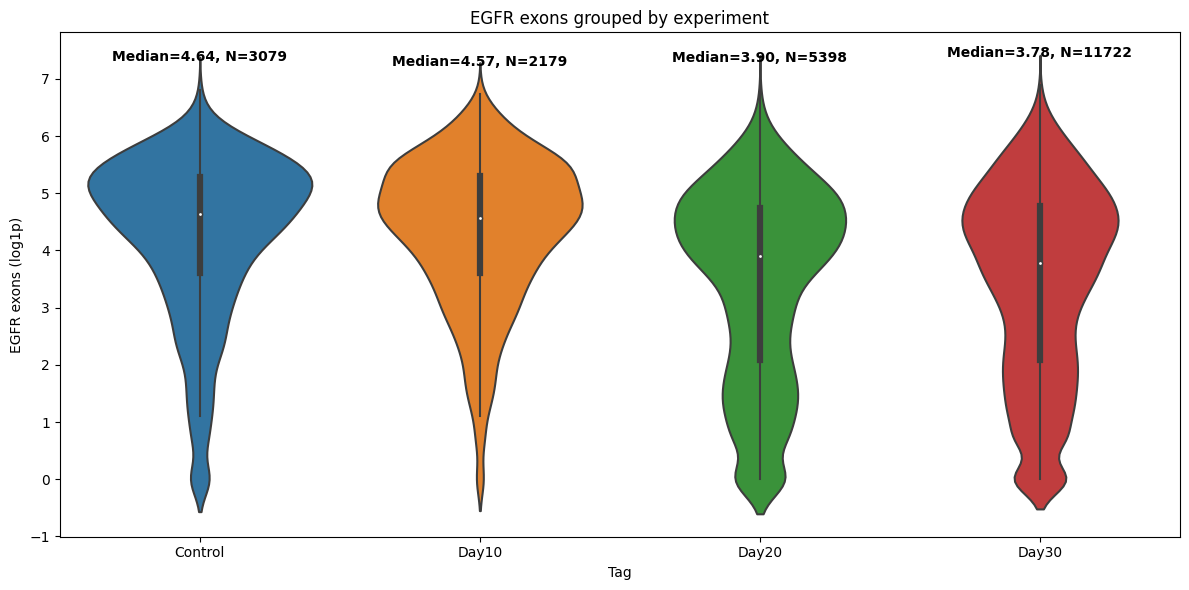

In [28]:
## EGFR exons (log1p)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))
ax = sns.violinplot(data=df_test, x='tag_plot', y='EGFR-exon_log1p', order=tag_plot_selected)

# Loop through each category and add median + N above the violin
for i, tag in enumerate(tag_plot_selected):
    values = df_test.loc[df_test['tag_plot'] == tag, 'EGFR-exon_log1p'].dropna()
    median = np.median(values)
    N = len(values)
    ymax = values.max()  # top of the violin
    ax.text(i, ymax + 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0]), 
            f"Median={median:.2f}, N={N}",
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.xlabel('Tag')
plt.ylabel('EGFR exons (log1p)')
plt.title('EGFR exons grouped by experiment')
plt.tight_layout()

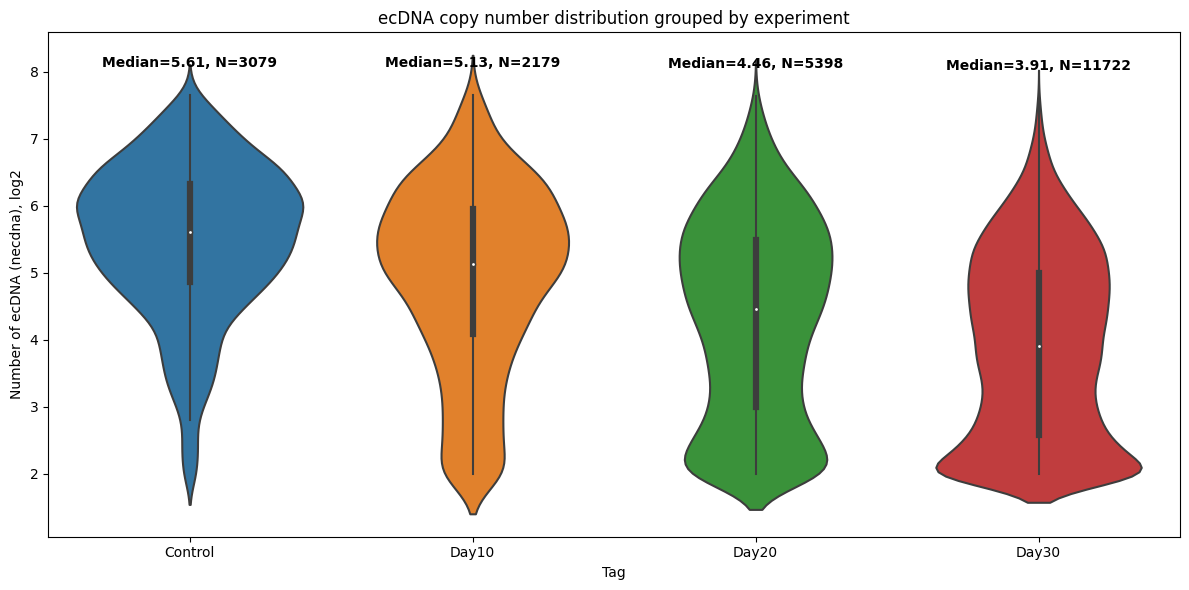

In [29]:
## copy number (log2)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


plt.figure(figsize=(12, 6))
ax = sns.violinplot(data=df_test, x='tag_plot', y='necdna_log2', order=tag_plot_selected)

# Loop through each category and add median + N above the violin
for i, tag in enumerate(tag_plot_selected):
    values = df_test.loc[df_test['tag_plot'] == tag, 'necdna_log2'].dropna()
    median = np.median(values)
    N = len(values)
    ymax = values.max()  # top of the violin
    ax.text(i, ymax + 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0]), 
            f"Median={median:.2f}, N={N}",
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.xlabel('Tag')
plt.ylabel('Number of ecDNA (necdna), log2')
plt.title('ecDNA copy number distribution grouped by experiment')
plt.tight_layout()


# keep text as text (editable in Illustrator/Inkscape)
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'

# (optional) belt-and-suspenders: ensure nothing is rasterized
for coll in ax.collections:
    coll.set_rasterized(False)

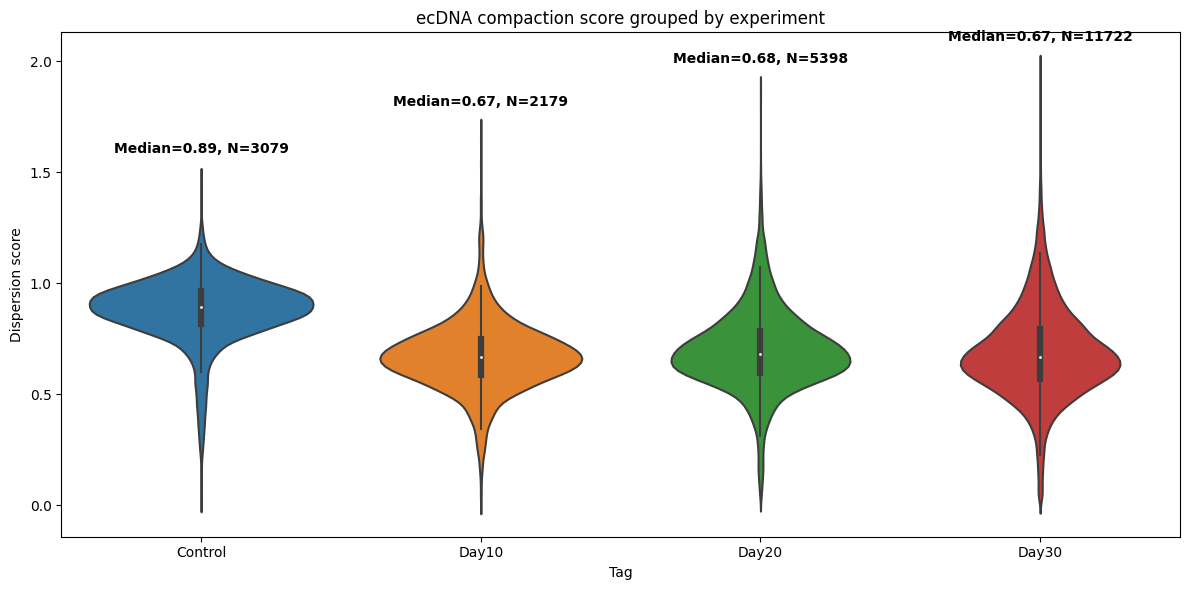

In [30]:
## dispersion score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))
ax = sns.violinplot(data=df_test, x='tag_plot', y='norm_rg', order=tag_plot_selected)

# Loop through each category and add median + N above the violin
for i, tag in enumerate(tag_plot_selected):
    values = df_test.loc[df_test['tag_plot'] == tag, 'norm_rg'].dropna()
    median = np.median(values)
    N = len(values)
    ymax = values.max()  # top of the violin
    ax.text(i, ymax + 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0]), 
            f"Median={median:.2f}, N={N}",
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.xlabel('Tag')
plt.ylabel('Dispersion score')
plt.title('ecDNA compaction score grouped by experiment')
plt.tight_layout()

# statistical test

For each feature, we used two statistical tests. Kruskal to show that at least one group is different from the rest, and if True, we followed up with a Mann-Whitney U test (with Benjamini–Hochberg multiple test corrections) between the Control (Day 0) and Day 30 to show the effect of co culture.  

In [31]:
import numpy as np
import pandas as pd
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests


def kruskal_dunn_posthoc(
    df: pd.DataFrame,
    val_col: str,
    group_col: str = "tag_plot",
    *,
    dropna: bool = True,
    p_adjust: str = "fdr_bh",   # 'bonferroni', 'holm', 'fdr_bh', etc.
    dunn_method: str = "auto",  # 'auto'|'dunn'|'mw'
):
    """
    Kruskal–Wallis + post-hoc pairwise comparisons.

    - Global test: Kruskal–Wallis across all groups.
    - Post-hoc:
        * If scikit-posthocs is installed: Dunn's test (recommended).
        * Otherwise (or if dunn_method='mw'): pairwise Mann–Whitney U with p-adjust
          (common alternative, but NOT exactly Dunn's test).

    Returns
    -------
    global_res : dict
        {'H','p','n_groups','group_sizes'}
    pairwise_df : pandas.DataFrame
        Rows: pairwise comparisons with raw and adjusted p-values.
    dunn_matrix : pandas.DataFrame or None
        If Dunn ran via scikit-posthocs, returns the full p-value matrix (adjusted).
        Else None.
    """
    if val_col not in df.columns:
        raise KeyError(f"val_col='{val_col}' not found in df.")
    if group_col not in df.columns:
        raise KeyError(f"group_col='{group_col}' not found in df.")

    X = df[[group_col, val_col]].copy()
    if dropna:
        X = X.dropna(subset=[group_col, val_col])

    # Build groups
    grp = X.groupby(group_col, sort=True)[val_col]
    names = list(grp.groups.keys())
    arrays = [grp.get_group(k).to_numpy() for k in names]
    sizes = {k: int(len(grp.get_group(k))) for k in names}

    if len(arrays) < 2:
        raise ValueError("Need at least 2 groups for Kruskal–Wallis / post-hoc tests.")
    if any(n < 1 for n in sizes.values()):
        raise ValueError("All groups must have at least 1 observation.")

    # Global Kruskal–Wallis
    H, p_kw = kruskal(*arrays)
    global_res = {"H": float(H), "p": float(p_kw), "n_groups": len(arrays), "group_sizes": sizes}

    # Decide post-hoc method
    use_dunn = (dunn_method in ("auto", "dunn"))
    dunn_matrix = None
    pairwise_rows = []

    if use_dunn:
        try:
            import scikit_posthocs as sp  # pip install scikit-posthocs

            # scikit-posthocs returns a square matrix of p-values
            dunn_matrix = sp.posthoc_dunn(
                X, val_col=val_col, group_col=group_col, p_adjust=p_adjust
            )
            # convert matrix to long-form comparisons (upper triangle)
            for i in range(len(names)):
                for j in range(i + 1, len(names)):
                    gi, gj = names[i], names[j]
                    p_adj = float(dunn_matrix.loc[gi, gj])
                    pairwise_rows.append(
                        {"group1": gi, "group2": gj, "p_raw": np.nan, "p_adj": p_adj, "method": "dunn"}
                    )

            pairwise_df = pd.DataFrame(pairwise_rows).sort_values("p_adj", kind="mergesort").reset_index(drop=True)
            return global_res, pairwise_df, dunn_matrix

        except Exception:
            # fall back below
            pass

    # Fallback / explicit MW: pairwise Mann–Whitney U + p-adjust
    # (Often acceptable, but technically different from Dunn.)
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            gi, gj = names[i], names[j]
            a, b = grp.get_group(gi).to_numpy(), grp.get_group(gj).to_numpy()
            stat, p_raw = mannwhitneyu(a, b, alternative="two-sided")
            pairwise_rows.append(
                {"group1": gi, "group2": gj, "U": float(stat), "p_raw": float(p_raw), "method": "mannwhitneyu"}
            )

    pairwise_df = pd.DataFrame(pairwise_rows)
    rej, p_adj, _, _ = multipletests(pairwise_df["p_raw"].to_numpy(), method=p_adjust)
    pairwise_df["p_adj"] = p_adj
    pairwise_df["reject"] = rej
    pairwise_df = pairwise_df.sort_values("p_adj", kind="mergesort").reset_index(drop=True)

    return global_res, pairwise_df, dunn_matrix


In [35]:
global_res, pairwise_df, dunn_mat = kruskal_dunn_posthoc(df_test, "necdna", "tag_plot", dunn_method="mw")
print(global_res)
pairwise_df[(pairwise_df['group1'] == 'Control') & (pairwise_df['group2'] == 'Day30')]

{'H': 3284.8308001328387, 'p': 0.0, 'n_groups': 4, 'group_sizes': {'Control': 3079, 'Day10': 2179, 'Day20': 5398, 'Day30': 11722}}


,group1,group2,U,p_raw,method,p_adj,reject
0,Control,Day30,29249361.0,0.0,mannwhitneyu,0.0,True


In [36]:
global_res, pairwise_df, dunn_mat = kruskal_dunn_posthoc(df_test, "EGFR-exon_log1p", "tag_plot", dunn_method="mw")
print(global_res)
pairwise_df[(pairwise_df['group1'] == 'Control') & (pairwise_df['group2'] == 'Day30')]

{'H': 1133.3062950899073, 'p': 2.1635218439539528e-245, 'n_groups': 4, 'group_sizes': {'Control': 3079, 'Day10': 2179, 'Day20': 5398, 'Day30': 11722}}


,group1,group2,U,p_raw,method,p_adj,reject
0,Control,Day30,23466895.5,1.319755e-145,mannwhitneyu,7.918532e-145,True


In [37]:
global_res, pairwise_df, dunn_mat = kruskal_dunn_posthoc(df_test, "norm_rg", "tag_plot", dunn_method="mw")
print(global_res)
pairwise_df[(pairwise_df['group1'] == 'Control') & (pairwise_df['group2'] == 'Day30')]

{'H': 3190.638829332034, 'p': 0.0, 'n_groups': 4, 'group_sizes': {'Control': 3079, 'Day10': 2179, 'Day20': 5398, 'Day30': 11722}}


,group1,group2,U,p_raw,method,p_adj,reject
2,Control,Day30,29079823.0,0.0,mannwhitneyu,0.0,True
